# Modeling: Cluster Split

Run after `feature_selection.ipynb`. Outputs → `outputs/cluster_split/`.

1. **k selection** — elbow (inertia) + silhouette for each `top_*` feature set.
2. **You choose k** — fill `N_CLUSTERS_BY_FEATURE_SET` (placeholders below).
3. **Cluster vs y** — target rate, lift, and balance per cluster at your k.
4. **OOF sweep** — cluster-split for every feature set; export best OOF business score.


In [1]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import pandas as pd

from cost_effective.models import ClusterSplitConfig
from cost_effective.notebook_setup import setup_modeling_notebook
from cost_effective.notebook_workflows import (
    analyze_cluster_k_for_feature_sets,
    analyze_cluster_y_distributions,
    cluster_split_feature_sets,
    compare_cluster_split_feature_sets,
    export_cluster_split_test_predictions,
    stage_matrices,
)
from cost_effective.paths import APPROACH_CLUSTER_SPLIT
from cost_effective.plots import (
    plot_cluster_k_selection_grid,
    plot_cluster_y_profile,
    plot_cluster_y_profiles_grid,
    plot_topk_oof_profit_curve,
)

In [3]:
ctx = setup_modeling_notebook(APPROACH_CLUSTER_SPLIT)
_, y_train, x_test, x_stage2 = stage_matrices(ctx)

TOP_K_CANDIDATES = cluster_split_feature_sets(ctx)
pd.DataFrame(
    {
        "n_features": [len(v) for v in TOP_K_CANDIDATES.values()],
        "features": [", ".join(v) for v in TOP_K_CANDIDATES.values()],
    },
    index=TOP_K_CANDIDATES.keys(),
)

,n_features,features
top_01,1,var_389
top_03,3,"var_389, var_308, var_93"
top_04,4,"var_389, var_308, var_93, var_87"
top_05,5,"var_389, var_308, var_93, var_87, var_254"
top_08,8,"var_389, var_308, var_93, var_87, var_254, var..."
top_10,10,"var_389, var_308, var_93, var_87, var_254, var..."
top_15,15,"var_389, var_308, var_93, var_87, var_254, var..."
top_20,20,"var_389, var_308, var_93, var_87, var_254, var..."
top_26,26,"var_389, var_308, var_93, var_87, var_254, var..."


## Step 1 — k diagnostics (elbow + silhouette)

Adjust `K_RANGE` if needed. Pick k from curves + `cluster_k_details.csv`.


In [4]:
K_RANGE = range(2, 11)

k_summary, k_details = analyze_cluster_k_for_feature_sets(
    ctx,
    TOP_K_CANDIDATES,
    k_values=K_RANGE,
)
k_summary

,feature_set,n_features,k_min,k_max
0,top_01,1,2,10
1,top_03,3,2,10
2,top_04,4,2,10
3,top_05,5,2,10
4,top_08,8,2,10
5,top_10,10,2,10
6,top_15,15,2,10
7,top_20,20,2,10
8,top_26,26,2,10


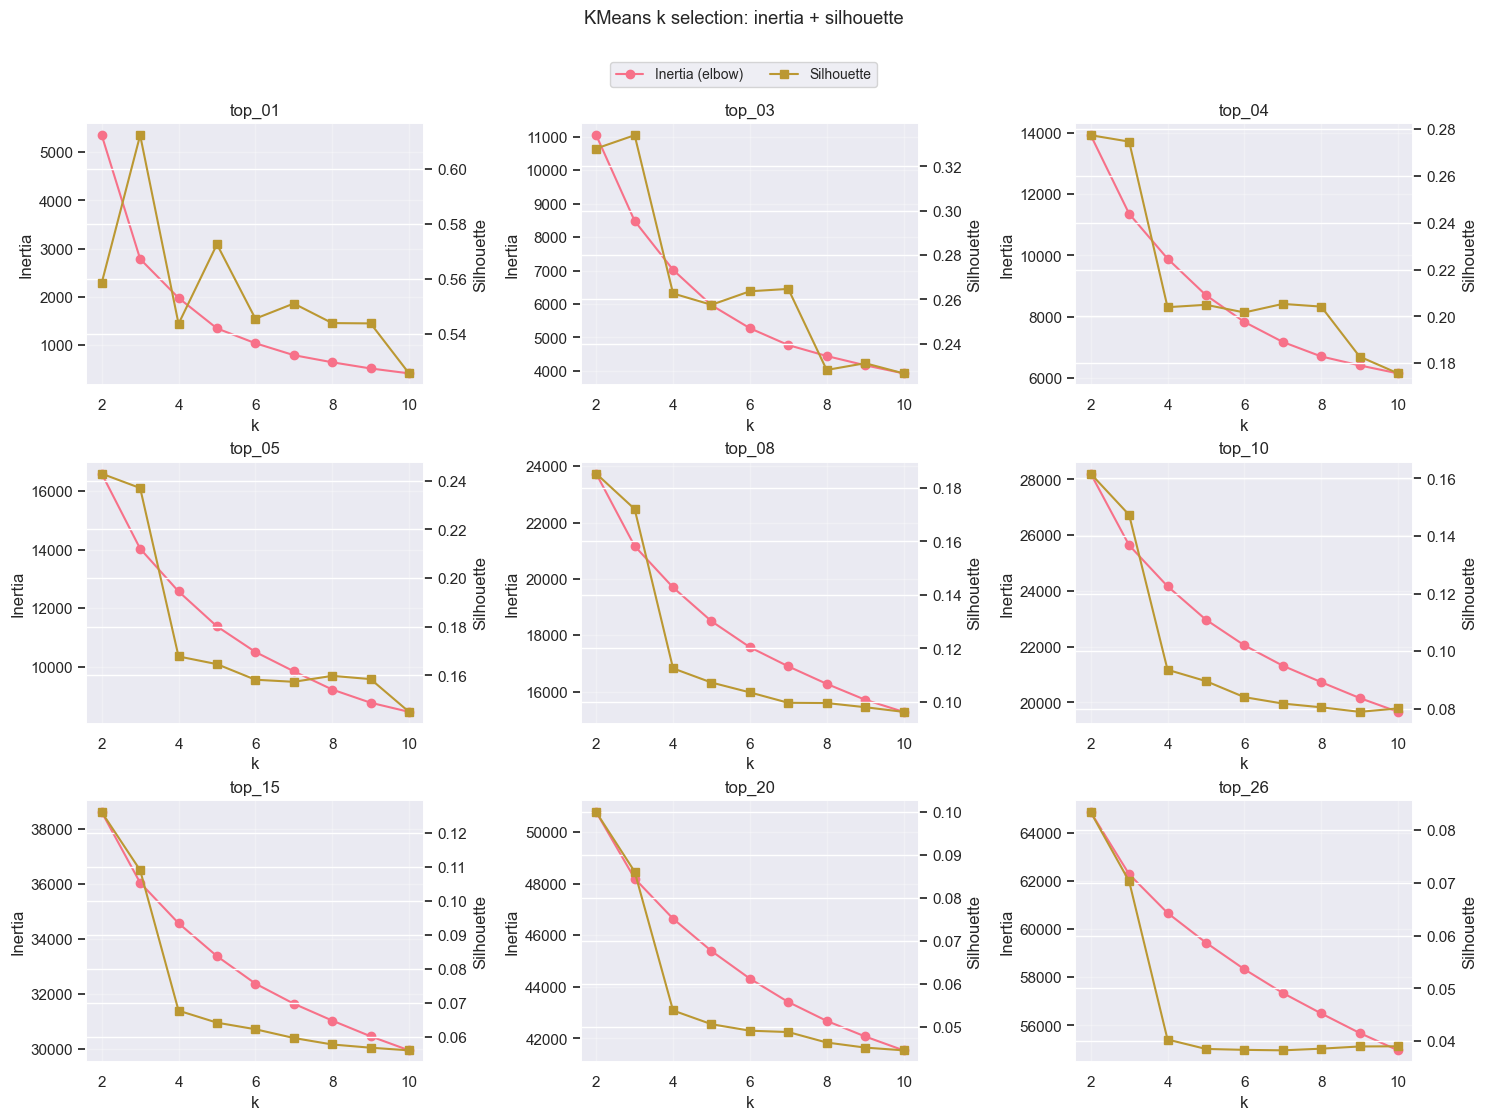

In [5]:
plot_cluster_k_selection_grid(k_details).show()

## Step 2 — choose k (fill before running OOF)

Set each `top_*` entry to an integer from Step 1, or set `DEFAULT_N_CLUSTERS` to apply one k to all sets.


In [6]:
DEFAULT_N_CLUSTERS: int | None = 4  # e.g. 2

# Per feature set
N_CLUSTERS_BY_FEATURE_SET: dict[str, int | None] = None

## Step 2b — y distribution at chosen k

Uses your `N_CLUSTERS_BY_FEATURE_SET` on full train. Check whether clusters separate positives (lift) and are large enough.

In [7]:
y_profiles = analyze_cluster_y_distributions(
    ctx,
    TOP_K_CANDIDATES,
    # N_CLUSTERS_BY_FEATURE_SET,
    default_n_clusters=DEFAULT_N_CLUSTERS,
)

y_summary = y_profiles.groupby("feature_set", as_index=False).agg(
    n_clusters=("n_clusters", "first"),
    global_positive_rate=("global_positive_rate", "first"),
    min_positive_rate=("positive_rate", "min"),
    max_positive_rate=("positive_rate", "max"),
    max_lift=("lift_vs_global", "max"),
    min_cluster_n=("n", "min"),
    max_cluster_n=("n", "max"),
)
y_summary.sort_values("max_lift", ascending=False)

,feature_set,n_clusters,global_positive_rate,min_positive_rate,max_positive_rate,max_lift,min_cluster_n,max_cluster_n
3,top_05,4,0.4976,0.382100,0.587580,1.180827,581,2497
2,top_04,4,0.4976,0.380531,0.585827,1.177305,565,2484
7,top_20,4,0.4976,0.386760,0.585327,1.176300,574,2494
1,top_03,4,0.4976,0.382867,0.584395,1.174427,572,2470
4,top_08,4,0.4976,0.380208,0.581616,1.168843,576,2463
6,top_15,4,0.4976,0.379252,0.577600,1.160772,588,2398
0,top_01,4,0.4976,0.340517,0.577265,1.160098,232,3087
5,top_10,4,0.4976,0.377856,0.575663,1.156879,569,2432
8,top_26,4,0.4976,0.382826,0.569157,1.143805,559,2040


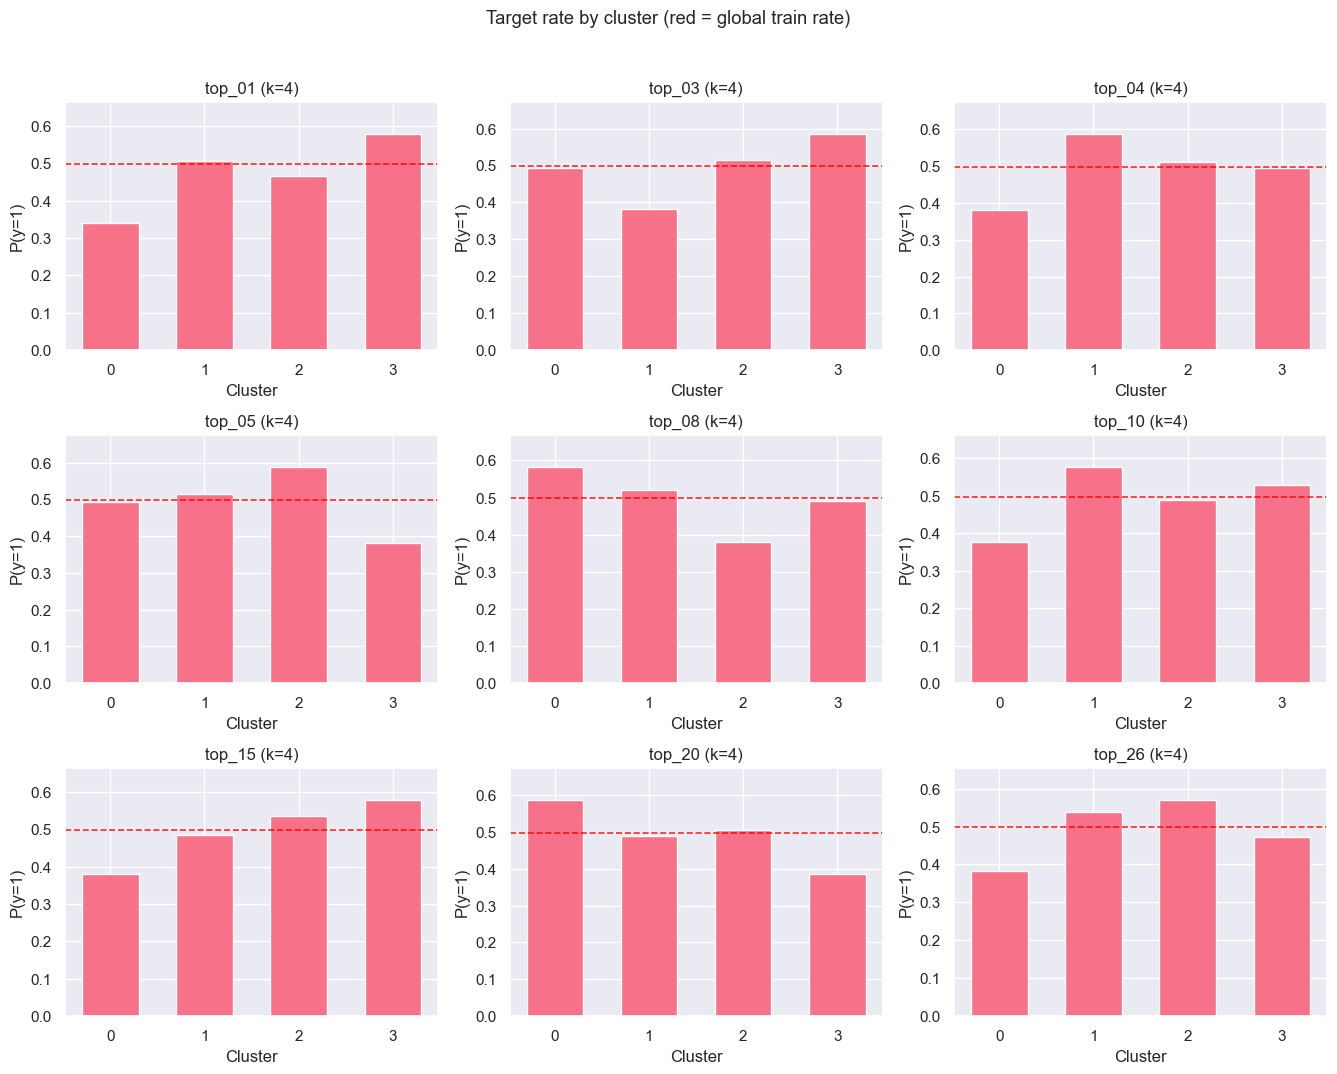

In [8]:
plot_cluster_y_profiles_grid(y_profiles).show()

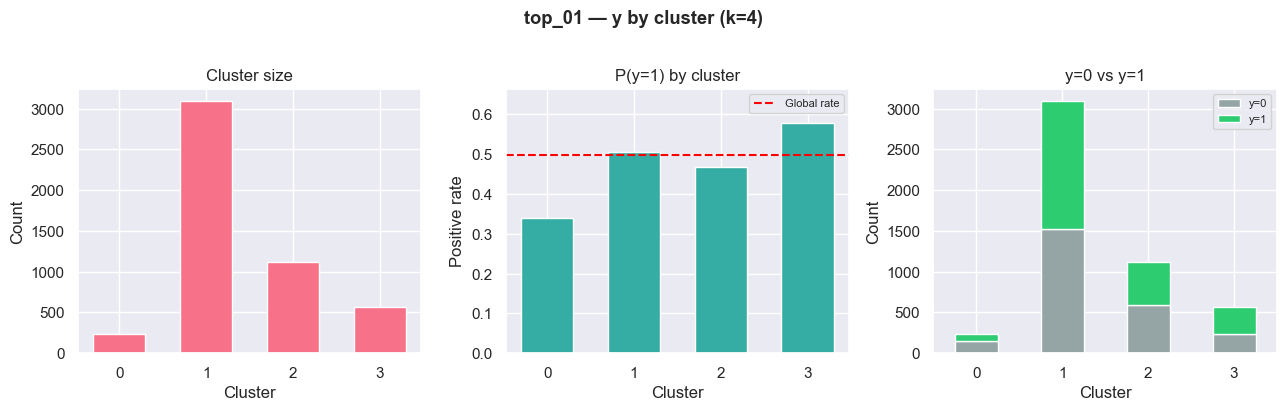

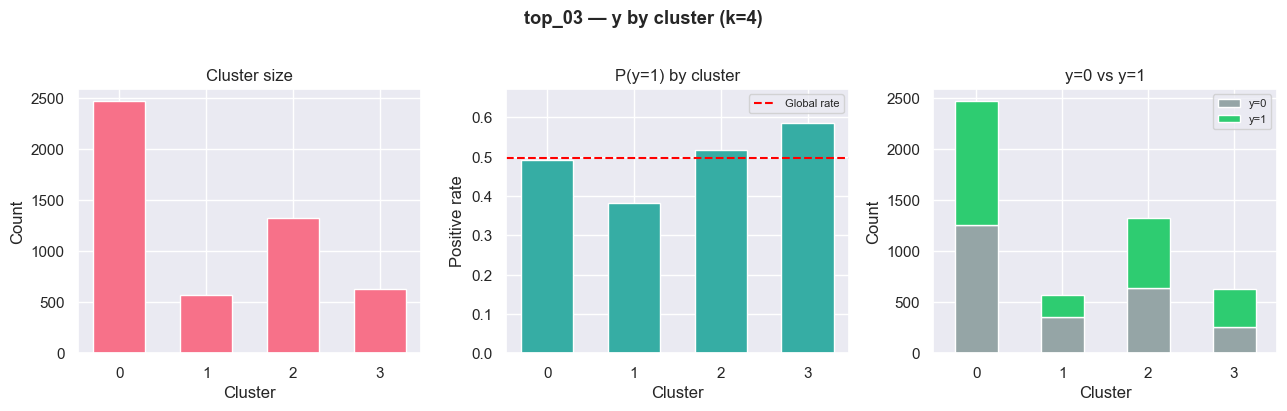

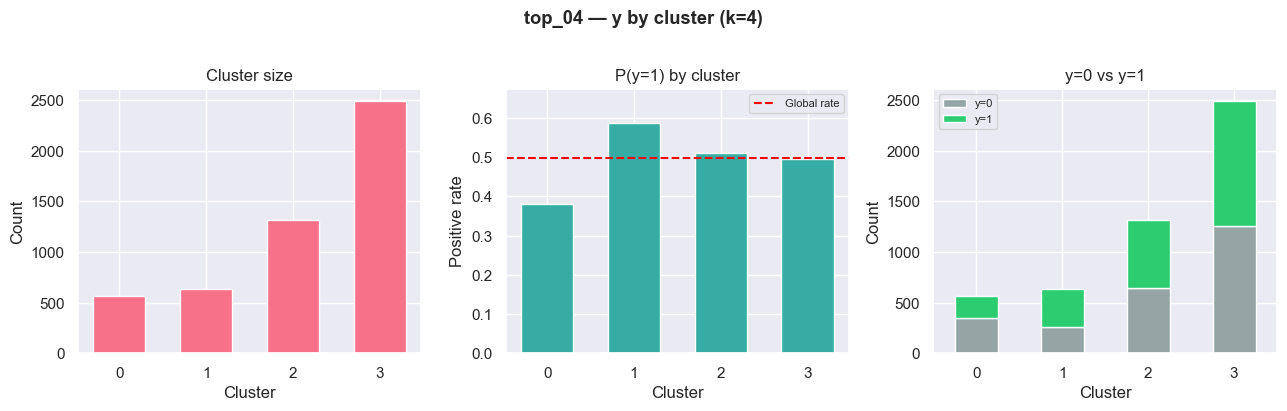

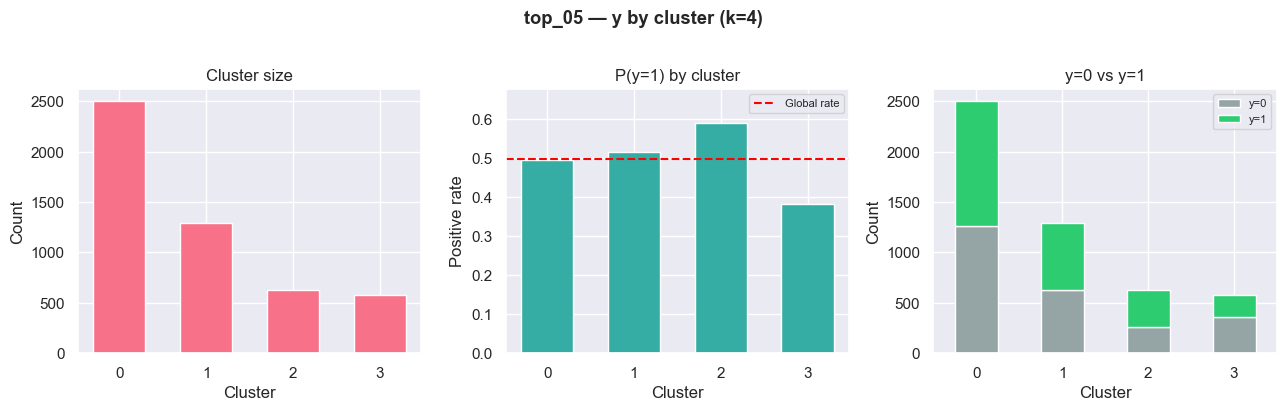

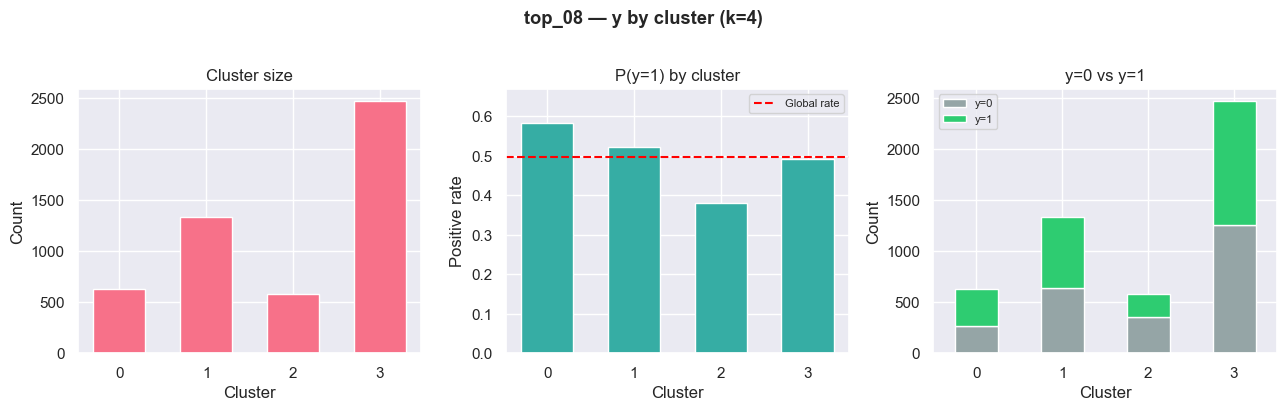

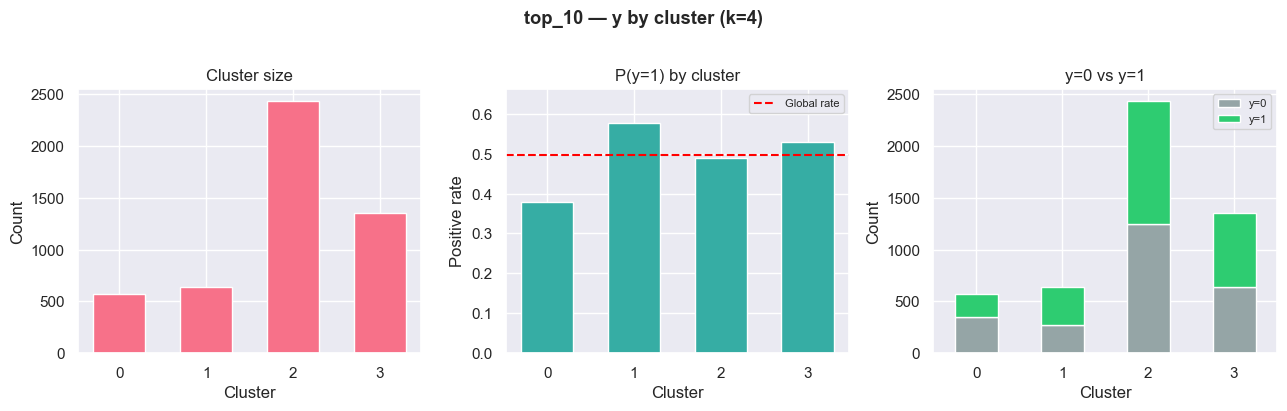

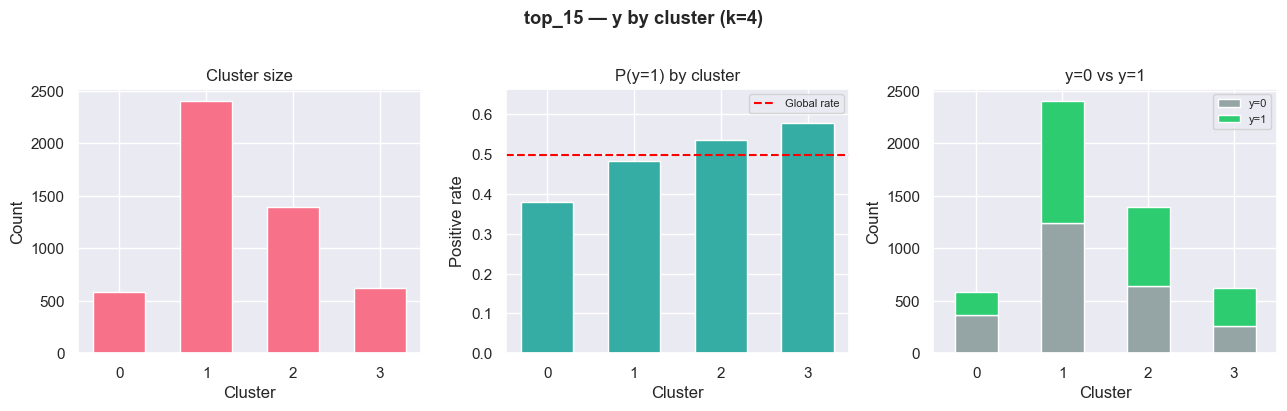

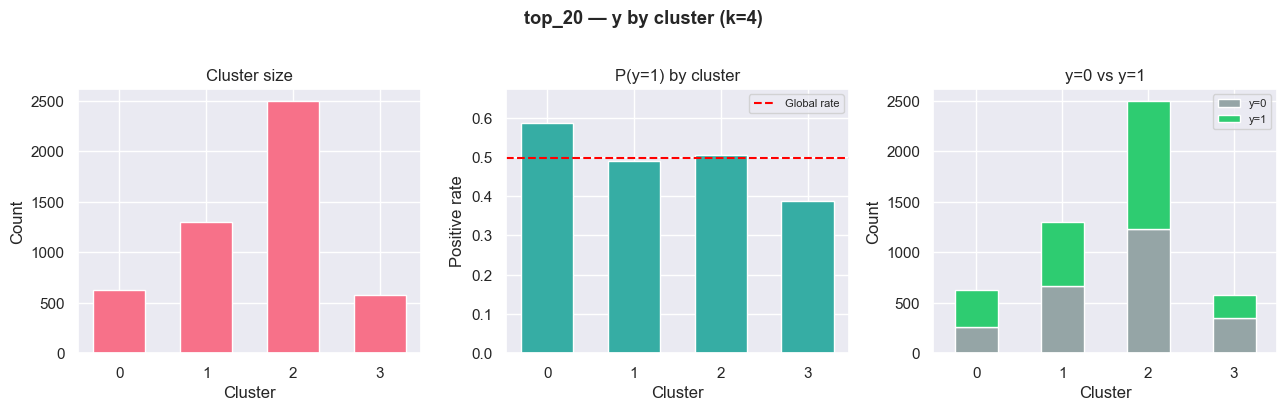

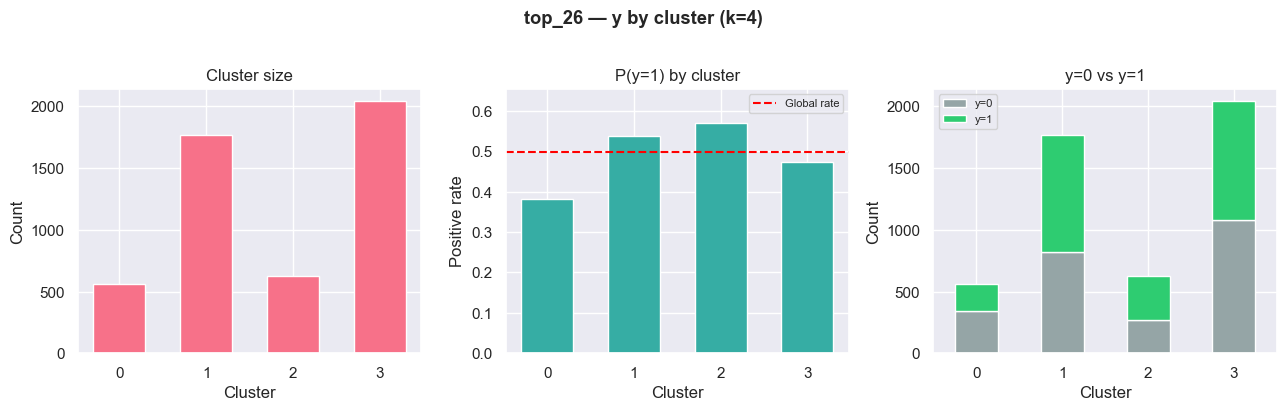

In [15]:
for feature_set in y_profiles["feature_set"].unique():
    sub = y_profiles.loc[y_profiles["feature_set"] == feature_set]
    plot_cluster_y_profile(
        sub,
        title=f"{feature_set} — y by cluster (k={int(sub['n_clusters'].iloc[0])})",
    ).show()

## Step 3 — OOF comparison and export


In [17]:
BASE = ClusterSplitConfig(feature_set="top_01", n_clusters=2, min_cluster_samples=80)

comparison, SPLIT, split_result, oof_eval = compare_cluster_split_feature_sets(
    ctx,
    TOP_K_CANDIDATES,
    base_config=BASE,
    # n_clusters_by_feature_set=N_CLUSTERS_BY_FEATURE_SET,
    default_n_clusters=DEFAULT_N_CLUSTERS,
)
print(
    f"Best: {SPLIT.feature_set} with k={SPLIT.n_clusters} "
    f"(OOF score {oof_eval.business_curve.best_score:.2f})"
)
comparison

Best: top_05 with k=4 (OOF score 3280.00)


,feature_set,n_features,n_clusters,oof_k,oof_business_score,cluster_counts_train
0,top_05,5,4,998,3280.0,"{0: 2497, 1: 1294, 2: 628, 3: 581}"
1,top_03,3,4,996,2880.0,"{0: 2470, 1: 572, 2: 1330, 3: 628}"
2,top_01,1,4,999,2800.0,"{0: 232, 1: 3087, 2: 1118, 3: 563}"
3,top_04,4,4,1000,2660.0,"{0: 565, 1: 635, 2: 1316, 3: 2484}"
4,top_08,8,4,1000,2370.0,"{0: 631, 1: 1330, 2: 576, 3: 2463}"
5,top_10,10,4,999,2260.0,"{0: 569, 1: 641, 2: 2432, 3: 1358}"
6,top_15,15,4,1000,1600.0,"{0: 588, 1: 2398, 2: 1389, 3: 625}"
7,top_20,20,4,987,425.0,"{0: 627, 1: 1305, 2: 2494, 3: 574}"
8,top_26,26,4,996,-895.0,"{0: 559, 1: 1772, 2: 629, 3: 2040}"


In [18]:
split_result.cluster_counts_train

{0: 2497, 1: 1294, 2: 628, 3: 581}

In [19]:
for line in oof_eval.summary_lines:
    print(line)
oof_eval.confusion_matrix

Business-optimal: k=998, threshold=0.5553, score=3280.00
F1-optimal: k=998, threshold=0.5553, f1=0.3546, roc_auc=0.5741, avg_precision=0.5810
Business curve TP=618, FP=380
F1 curve TP=618, FP=380
OOF profit-optimal k=998, break-even k=1000, effective k=998


,Predicted 0,Predicted 1
Actual 0,2132,380
Actual 1,1870,618


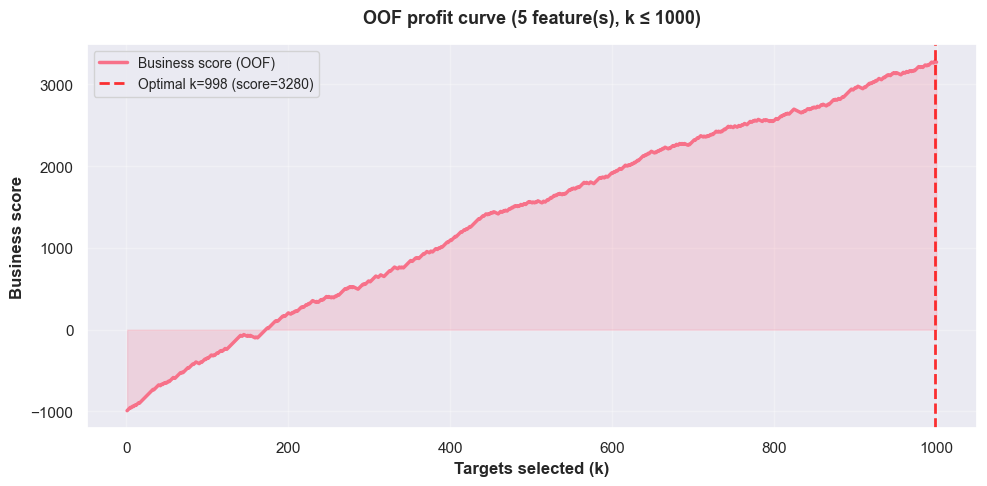

In [20]:
plot_topk_oof_profit_curve(
    oof_eval.business_curve,
    split_result.feature_count,
    ctx.max_targets,
).show()

In [21]:
predictions = export_cluster_split_test_predictions(
    ctx,
    split_result,
    x_stage2,
    y_train,
    x_test,
    oof_eval,
    SPLIT,
    TOP_K_CANDIDATES,
)
predictions.head()

,rank,sample_index,probability
0,1,4912,0.834894
1,2,4134,0.828639
2,3,4768,0.802190
3,4,2855,0.792287
4,5,2916,0.785878
